In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from sklearn.model_selection import train_test_split
from functools import reduce
from functools import partial
import operator
from timeit import default_timer
from matplotlib.ticker import FormatStrFormatter
import deepxde as dde
import scipy.io as scio

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# Parameters
epochs =1000
batch_size = 64
gamma = 0.5
learning_rate = 0.001
step_size= 50
modes=12
width=32
dim_x = 1
activation = "identity"
kernel = "Glorot normal"

In [3]:
# Create train/test splits
dataFile = "zx0"  
data = scio.loadmat(dataFile)
inpArr = data['zx0']
dataFile = "sigmax0"  
data = scio.loadmat(dataFile)
outArr = data['sigmax0']
x = np.array(inpArr, dtype=np.float32)
y = np.array(outArr, dtype=np.float32)

y = y.reshape(y.shape[1],1)
x = x.reshape(x.shape[1],1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)
x_train = torch.from_numpy(x_train).cuda()
y_train = torch.from_numpy(y_train).cuda()
x_test = torch.from_numpy(x_test).cuda()
y_test = torch.from_numpy(y_test).cuda()

trainData = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True, generator=torch.Generator(device='cuda'))
testData = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False, generator=torch.Generator(device='cuda'))

In [9]:
# Create train/test splits
dataFile = "zy0"  
data = scio.loadmat(dataFile)
inpArr = data['zy0']
dataFile = "sigmay0"  
data = scio.loadmat(dataFile)
outArr = data['sigmay0']
x = np.array(inpArr, dtype=np.float32)
y = np.array(outArr, dtype=np.float32)

y = y.reshape(y.shape[1],1)
x = x.reshape(x.shape[1],1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=1)
x_train = torch.from_numpy(x_train).cuda()
y_train = torch.from_numpy(y_train).cuda()
x_test = torch.from_numpy(x_test).cuda()
y_test = torch.from_numpy(y_test).cuda()

trainData = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True, generator=torch.Generator(device='cuda'))
testData = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False, generator=torch.Generator(device='cuda'))

In [4]:
def count_params(model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn
    return pp

In [5]:
class mymodel(nn.Module):
    def __init__(self, activation, kernel):
        super(mymodel, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 1)
        self.relu = torch.nn.SELU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x
       
model = mymodel(activation, kernel)
print(count_params(model))

12673


In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

In [7]:
loss = nn.MSELoss()
train_lossArr = []
test_lossArr = []
time_Arr = []

for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_loss = 0
    for x, y in trainData:
        x, y = x.cuda(), y.cuda()
        optimizer.zero_grad()
        out = model(x)
        lp = loss(out, y)
        lp.backward()
        
        optimizer.step()
        train_loss += lp.item()
        
    scheduler.step()
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in testData:
            x, y = x.cuda(), y.cuda()
            out = model(x)
            test_loss += loss(out, y).item()
            
    train_loss /= len(trainData)
    test_loss /= len(testData)
    
    train_lossArr.append(train_loss)
    test_lossArr.append(test_loss)
    
    t2 = default_timer()
    time_Arr.append(t2-t1)
    if ep%50 == 0:
        print(ep, t2-t1, np.mean(train_lossArr[-50:]), np.mean(test_lossArr[-50:]))

0 2.115126299999986 46.769447326660156 43.194950103759766
50 0.021562200000005305 4.09844611287117 2.760157084465027
100 0.03190689999999563 0.8497773377597332 0.48644679665565493
150 0.021537899999998444 0.18036576777696608 0.1387617665529251
200 0.029038599999978487 0.11650791980326175 0.09649798631668091
250 0.03083440000000337 0.08824674028903245 0.07606941401958466
300 0.020760099999989734 0.07475179854780435 0.06647783532738685
350 0.029132000000004155 0.06806154903024435 0.06133846923708916
400 0.028033599999986336 0.06440382046625018 0.058822648003697395
450 0.019972999999993135 0.06261234041303396 0.057516570389270785
500 0.02847840000001156 0.061400058139115574 0.05686650224030018
550 0.028048299999994697 0.0610369660705328 0.05652313053607941
600 0.020063899999996693 0.06070208491757512 0.056323342993855476
650 0.03316039999998566 0.06065904691815376 0.05621892690658569
700 0.0197227999999825 0.06042804138734937 0.05617723762989044
750 0.02138830000001235 0.06061301300302148

In [8]:
dataFile = "testdata"  
data = scio.loadmat(dataFile)
inpArr = data['testdata']
x = np.array(inpArr, dtype=np.float32)
x = x.reshape(x.shape[1],1)
x = torch.from_numpy(x).cuda()
out=model(x)
out=out.cpu()
scio.savemat('sxtest.mat',{'sxtest':out.detach().numpy()})

In [14]:
dataFile = "testdata"  
data = scio.loadmat(dataFile)
inpArr = data['testdata']
x = np.array(inpArr, dtype=np.float32)
x = x.reshape(x.shape[1],1)
x = torch.from_numpy(x).cuda()
out=model(x)
out=out.cpu()
scio.savemat('sytest.mat',{'sytest':out.detach().numpy()})

In [11]:
dataFile = "zxinitial"  
data = scio.loadmat(dataFile)
inpArr = data['zxinitial']
x = np.array(inpArr, dtype=np.float32)
x = x.reshape(x.shape[1],1)
x = torch.from_numpy(x).cuda()
out=model(x)
out=out.cpu()
scio.savemat('sx.mat',{'sx':out.detach().numpy()})

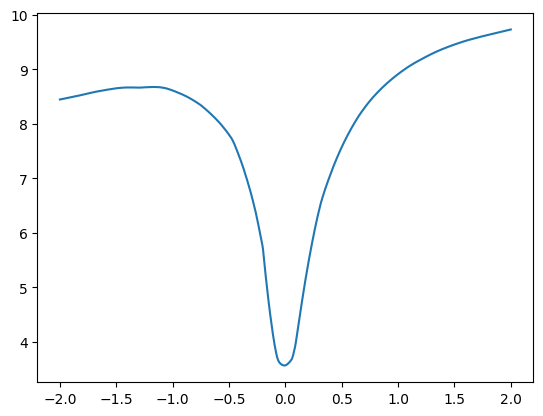

In [9]:
x=np.reshape(inpArr,[1000,1])
plt.figure
plt.plot(x,out.detach().numpy())

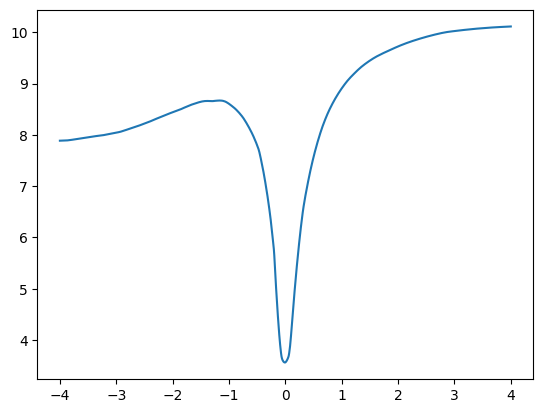

In [10]:
inpArr=np.linspace(-4,4,1000)
x = np.array(inpArr, dtype=np.float32)
x = x.reshape(x.shape[0],1)
x = torch.from_numpy(x).cuda()
out=model(x)
out=out.cpu()
x=np.reshape(inpArr,[1000,1])
plt.figure
plt.plot(x,out.detach().numpy())